✓ Imports successful
✓ Connected to database: thesis_final.duckdb
✓ 62,847 chunks loaded
  Time period: 2012-01-10 to 2022-12-20


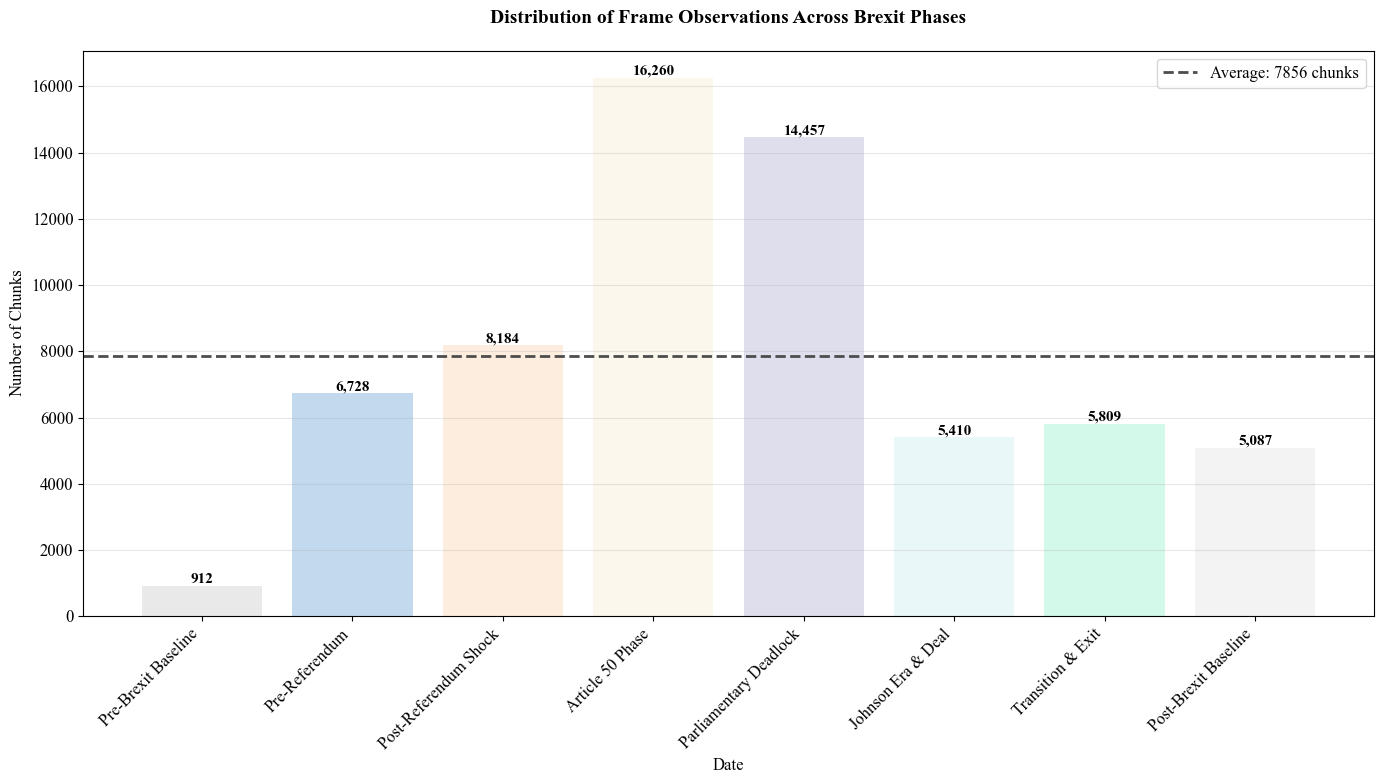


Distribution of Chunks Across Brexit Phases
Pre-Brexit Baseline           :    912 chunks ( 1.45%)
Pre-Referendum                :  6,728 chunks (10.71%)
Post-Referendum Shock         :  8,184 chunks (13.02%)
Article 50 Phase              : 16,260 chunks (25.87%)
Parliamentary Deadlock        : 14,457 chunks (23.00%)
Johnson Era & Deal            :  5,410 chunks ( 8.61%)
Transition & Exit             :  5,809 chunks ( 9.24%)
Post-Brexit Baseline          :  5,087 chunks ( 8.09%)
------------------------------------------------------------
Total                         : 62,847 chunks
Average per phase             :  7,856 chunks

✓ Database connection closed


In [3]:
# Import necessary libraries
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

# Database connection
DB_PATH = "thesis_final.duckdb"
conn = duckdb.connect(DB_PATH)

print("✓ Imports successful")
print(f"✓ Connected to database: {DB_PATH}")

# Definition of Brexit phases (mit den gleichen Farben wie PHASE_COLORS)
BREXIT_PHASES = {
    'Pre-Brexit Baseline': {
        'start': date(2012, 1, 1),
        'end': date(2013, 1, 22),
        'color': '#E6E6E6'
    },
    'Pre-Referendum': {
        'start': date(2013, 1, 23),
        'end': date(2016, 6, 22),
        'color': '#B8D3EB'
    },
    'Post-Referendum Shock': {
        'start': date(2016, 6, 23),
        'end': date(2017, 3, 28),
        'color': '#FDEAD9'
    },
    'Article 50 Phase': {
        'start': date(2017, 3, 29),
        'end': date(2018, 11, 13),
        'color': '#FBF6E9'
    },
    'Parliamentary Deadlock': {
        'start': date(2018, 11, 14),
        'end': date(2019, 7, 23),
        'color': '#D9D9EA'
    },
    'Johnson Era & Deal': {
        'start': date(2019, 7, 24),
        'end': date(2020, 1, 30),
        'color': '#E7F6F8'
    },
    'Transition & Exit': {
        'start': date(2020, 1, 31),
        'end': date(2020, 12, 31),
        'color': '#CCF8E7'
    },
    'Post-Brexit Baseline': {
        'start': date(2021, 1, 1),
        'end': date(2022, 12, 31),
        'color': '#F2F2F2'
    }
}

# Load chunks data
query = """
SELECT 
    c.chunk_id,
    c.debate_id,
    c.speech_id,
    c.frame_label as frame,
    d.date,
    d.major_heading_text
FROM chunks c
JOIN debates d ON c.debate_id = d.debate_id
WHERE c.frame_label IS NOT NULL
ORDER BY d.date
"""

df_chunks = conn.execute(query).df()
df_chunks['date'] = pd.to_datetime(df_chunks['date'])

print(f"✓ {len(df_chunks):,} chunks loaded")
print(f"  Time period: {df_chunks['date'].min().date()} to {df_chunks['date'].max().date()}")

# Assign each chunk to a Brexit phase
def assign_phase(chunk_date):
    for phase, info in BREXIT_PHASES.items():
        if info['start'] <= chunk_date.date() <= info['end']:
            return phase
    return None

df_chunks['phase'] = df_chunks['date'].apply(assign_phase)

# Count chunks per phase
phase_counts = df_chunks.groupby('phase').size().reset_index(name='count')

# Calculate average (mean) chunks per phase
average_chunks = phase_counts['count'].mean()

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Define phase order
phase_order = list(BREXIT_PHASES.keys())
phase_counts['phase'] = pd.Categorical(phase_counts['phase'], categories=phase_order, ordered=True)
phase_counts = phase_counts.sort_values('phase')

# Get colors for each phase
colors = [BREXIT_PHASES[phase]['color'] for phase in phase_counts['phase']]

# Create bar chart (ohne edgecolor)
bars = ax.bar(range(len(phase_counts)), phase_counts['count'], color=colors, alpha=0.85)

# Add average line
ax.axhline(y=average_chunks, color='#4D4D4D', linestyle='--', linewidth=2, 
           label=f'Average: {average_chunks:.0f} chunks')

# Customize plot
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Chunks', fontsize=12)
ax.set_title('Distribution of Frame Observations Across Brexit Phases', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(phase_counts)))
ax.set_xticklabels(phase_counts['phase'], rotation=45, ha='right', fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=12, loc='upper right')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, phase_counts['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count):,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("Distribution of Chunks Across Brexit Phases")
print("="*60)
for phase, count in zip(phase_counts['phase'], phase_counts['count']):
    percentage = (count / len(df_chunks)) * 100
    print(f"{phase:30s}: {count:6,} chunks ({percentage:5.2f}%)")
print("-"*60)
print(f"{'Total':30s}: {len(df_chunks):6,} chunks")
print(f"{'Average per phase':30s}: {average_chunks:6,.0f} chunks")
print("="*60)

# Close database connection
conn.close()
print("\n✓ Database connection closed")